In [1]:
from astropy import constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt

NR = 105
NZ = 105
NT = 500
Rf = np.linspace(-2,102,NR)
Zf = np.linspace(-2,102,NZ)
Rc = (Rf[1:] + Rf[:-1]) /2
Zc = (Zf[1:] + Zf[:-1]) /2
Rc

array([ -1.5,  -0.5,   0.5,   1.5,   2.5,   3.5,   4.5,   5.5,   6.5,
         7.5,   8.5,   9.5,  10.5,  11.5,  12.5,  13.5,  14.5,  15.5,
        16.5,  17.5,  18.5,  19.5,  20.5,  21.5,  22.5,  23.5,  24.5,
        25.5,  26.5,  27.5,  28.5,  29.5,  30.5,  31.5,  32.5,  33.5,
        34.5,  35.5,  36.5,  37.5,  38.5,  39.5,  40.5,  41.5,  42.5,
        43.5,  44.5,  45.5,  46.5,  47.5,  48.5,  49.5,  50.5,  51.5,
        52.5,  53.5,  54.5,  55.5,  56.5,  57.5,  58.5,  59.5,  60.5,
        61.5,  62.5,  63.5,  64.5,  65.5,  66.5,  67.5,  68.5,  69.5,
        70.5,  71.5,  72.5,  73.5,  74.5,  75.5,  76.5,  77.5,  78.5,
        79.5,  80.5,  81.5,  82.5,  83.5,  84.5,  85.5,  86.5,  87.5,
        88.5,  89.5,  90.5,  91.5,  92.5,  93.5,  94.5,  95.5,  96.5,
        97.5,  98.5,  99.5, 100.5, 101.5])

(0.1, 10000.0)

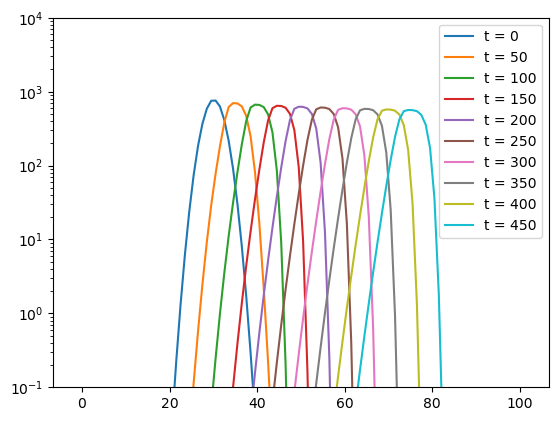

In [2]:
ndis_C = np.fromfile("ndis_C.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)

for i in range(NT):
    if not i%50:
        plt.plot(Zc, ndis_C[i, 30], label = f"t = {i}")
plt.yscale("log")
plt.legend()
plt.ylim(1e-1,1e4)

Text(0.5, 1.0, 'Total number of particles VS time')

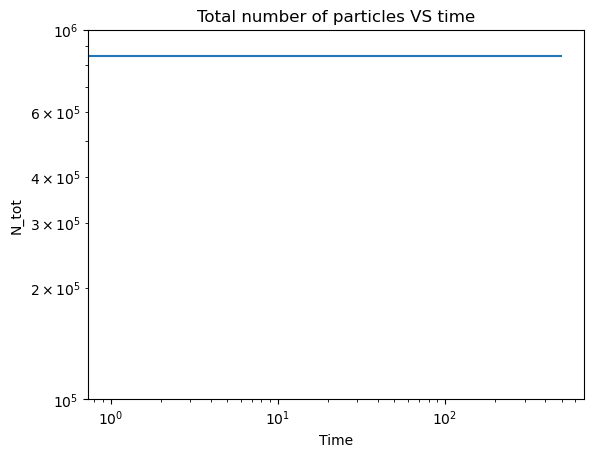

In [3]:
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
N_tot = np.sum(ndis_C * dV[None,:], axis = (1,2))
t = np.arange(500)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e5,1e6)
plt.ylabel("N_tot")
plt.xlabel("Time")
plt.title("Total number of particles VS time")

Text(0.5, 1.0, 'Distribution extension VS time')

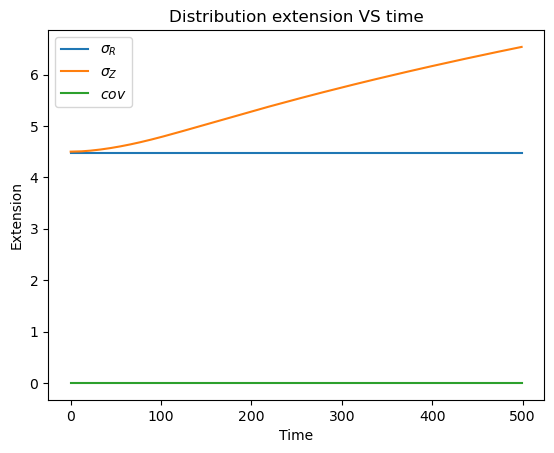

In [4]:

mc_R = np.sum(ndis_C * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
mc_Z = np.sum(ndis_C * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot

sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis_C * dV[None,:], axis = (1,2)) / N_tot 
sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis_C * dV[None,:], axis = (1,2)) / N_tot 
cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis_C*dV[None,:,:],axis=(1,2))/N_tot
plt.plot(t, sigma_R, label = f"$\sigma_R$")
plt.plot(t, sigma_Z, label = f"$\sigma_Z$")
plt.plot(t, cov, label = f"$cov$")
plt.legend()
plt.ylabel("Extension")
plt.xlabel("Time")
plt.title("Distribution extension VS time")

(0.1, 10000.0)

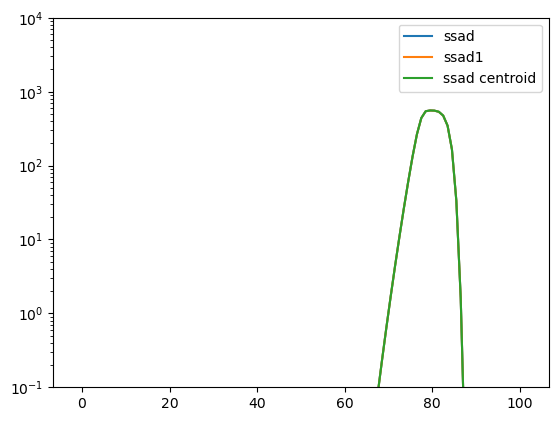

In [11]:
ndis_C1 = np.fromfile("ndis_C_t_ssad.bin",dtype = np.float64).reshape(NR - 1, NZ - 1)
ndis_C2 = np.fromfile("ndis_C_t_ssad_1.bin",dtype = np.float64).reshape(NR - 1, NZ - 1)
ndis_C3 = np.fromfile("ndis_C_t_ssad_centroid.bin",dtype = np.float64).reshape(NR - 1, NZ - 1)

plt.plot(Zc, 1000*ndis_C1[30], label = f"ssad")
plt.plot(Zc, 1000*ndis_C2[30], label = f"ssad1")
plt.plot(Zc, 1000*ndis_C3[30], label = f"ssad centroid")

# plt.plot(Zc, ndis_C[-1,30], label = f"1st order")

plt.yscale("log")
plt.legend()
plt.ylim(1e-1,1e4)

In [6]:
ndis_C[]

0

In [24]:
R

array([ -2.,  -1.,   0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,
         9.,  10.,  11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,
        20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,
        31.,  32.,  33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,
        42.,  43.,  44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,
        53.,  54.,  55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,
        64.,  65.,  66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,
        75.,  76.,  77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,
        86.,  87.,  88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,
        97.,  98.,  99., 100., 101.])